In [14]:
# Parameters
param_use_own_data = 0
param_earlier_geotiff_file = 'geotiff_AHN3_perc_95_normalized_height.tif'
param_later_geotiff_file = 'geotiff_AHN4_perc_95_normalized_height.tif'

# Imports
import shutil
from pathlib import Path
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# Configuration
conf_cloud_storage = '/home/jovyan/Cloud Storage/'
conf_public_bucket = 'naa-vre-public/'
conf_user_bucket = 'naa-vre-user-data/'
conf_laserfarm_workshop = 'vl-laserfarm/Workshop/'
conf_geotiff = 'geotiff/'
conf_local_tmp = '/tmp/data'
conf_geotiff = 'geotiff'
conf_local_path_geotiff = Path(conf_local_tmp) / conf_geotiff

In [15]:
# Retrieve geotiffs from cloud storage
from pathlib import Path

def get_file_from_local_cloud_storage(filename: str) -> str:
    cloud_file_path = Path(directory_to_retrieve) / filename
    local_file_path = Path(conf_local_path_geotiff) / filename
    print(f'Downloading{cloud_file_path} to {local_file_path}')
    shutil.copy(cloud_file_path, local_file_path)
    return local_file_path

Path(conf_local_path_geotiff).mkdir(parents=True, exist_ok=True)

if param_use_own_data:
    directory_to_retrieve = Path(conf_cloud_storage) / conf_user_bucket / conf_geotiff
else:
    directory_to_retrieve = Path(conf_cloud_storage) / conf_public_bucket / conf_laserfarm_workshop / conf_geotiff

earlier_geotiff_file = get_file_from_local_cloud_storage(param_earlier_geotiff_file)
later_geotiff_file = get_file_from_local_cloud_storage(param_later_geotiff_file)

Downloading/home/jovyan/Cloud Storage/naa-vre-public/vl-laserfarm/Workshop/geotiff/geotiff_AHN3_perc_95_normalized_height.tif to /tmp/data/geotiff/geotiff_AHN3_perc_95_normalized_height.tif
Downloading/home/jovyan/Cloud Storage/naa-vre-public/vl-laserfarm/Workshop/geotiff/geotiff_AHN4_perc_95_normalized_height.tif to /tmp/data/geotiff/geotiff_AHN4_perc_95_normalized_height.tif


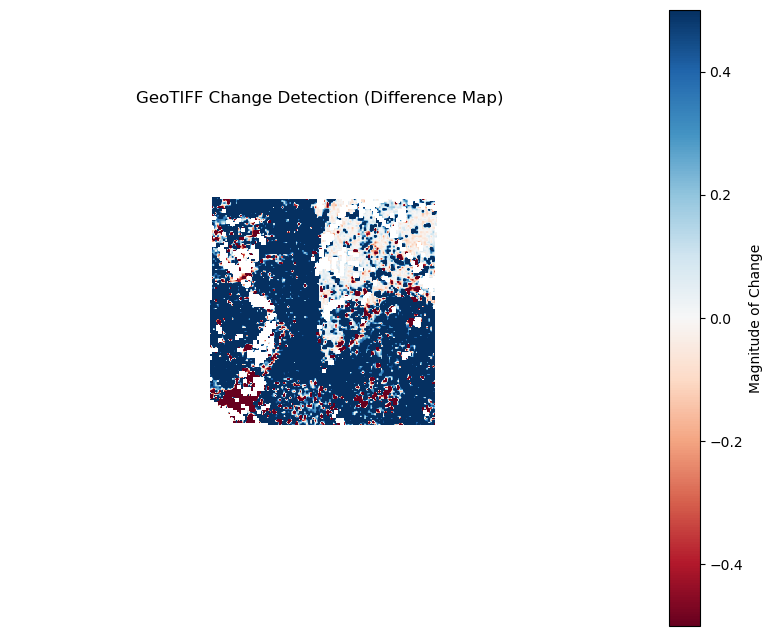

In [16]:
# Change detection
def calculate_change(path_before, path_after):
    with rasterio.open(path_before) as src_before:
        # Read the first band
        data_before = src_before.read(1).astype('float32')
        meta = src_before.meta

    with rasterio.open(path_after) as src_after:
        data_after = src_after.read(1).astype('float32')

    # Ensure arrays are the same shape (basic check)
    if data_before.shape != data_after.shape:
        raise ValueError("Images have different dimensions! Resampling required.")

    # Calculate Difference (After - Before)
    # Positive values = increase; Negative values = decrease
    diff = data_after - data_before
    
    return diff, meta

diff_map, meta = calculate_change(earlier_geotiff_file, later_geotiff_file)

plt.figure(figsize=(10, 8))
img = plt.imshow(diff_map, cmap='RdBu', vmin=-0.5, vmax=0.5) 
plt.colorbar(img, label='Magnitude of Change')
plt.title('GeoTIFF Change Detection (Difference Map)')
plt.axis('off')
plt.show()